In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("C:\\Users\\17aya\\Downloads\\dataset\\data.csv")

df.head()



,text,source,prompt_id,text_length,word_count
0,"Federal law supersedes state law, and cannabis...",Bloom-7B,0,967,157
1,Miles feels restless after working all day. He...,Bloom-7B,0,5068,778
2,So first of I am danish. That means that I fol...,Bloom-7B,0,1602,267
3,In this paper we present a novel rule-based ap...,Bloom-7B,0,5469,848
4,"Most social progressives, love democracy, and ...",Bloom-7B,0,2379,380


In [2]:
df.describe()

,prompt_id,text_length,word_count
count,788922.000000,788922.000000,788922.000000
mean,420.069514,3123.374844,497.983404
std,1381.285340,4963.074433,720.866585
min,0.000000,105.000000,25.000000
25%,0.000000,647.000000,110.000000
50%,0.000000,1921.000000,324.000000
75%,0.000000,3910.000000,624.000000
max,9913.000000,890119.000000,71543.000000


In [3]:
df['source_binary'] = df['source'].apply(
    lambda x: 'HUMAN' if x.lower() == 'human' else 'AI'
)
df.head()

,text,source,prompt_id,text_length,word_count,source_binary
0,"Federal law supersedes state law, and cannabis...",Bloom-7B,0,967,157,AI
1,Miles feels restless after working all day. He...,Bloom-7B,0,5068,778,AI
2,So first of I am danish. That means that I fol...,Bloom-7B,0,1602,267,AI
3,In this paper we present a novel rule-based ap...,Bloom-7B,0,5469,848,AI
4,"Most social progressives, love democracy, and ...",Bloom-7B,0,2379,380,AI


In [4]:
#removing duplicates and missing values  any
df = df.dropna(subset=['text', 'source_binary'])
df = df.drop_duplicates(subset=['text'])

import re

def normalize_text(text):
    text = str(text).lower()
    text = re.sub(r'[\r\n\t]+', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['text'] = df['text'].apply(normalize_text)

df = df[df['word_count'] >= 10].copy()

In [5]:
def clean_for_tfidf(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\d+', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_text'] = df['text'].apply(clean_for_tfidf)

In [6]:
print(df.shape)
print(df['source_binary'].value_counts())
print(df[['text', 'clean_text', 'word_count','text_length']].head())

(788922, 7)
source_binary
AI       441230
HUMAN    347692
Name: count, dtype: int64
                                                text  \
0  federal law supersedes state law, and cannabis...   
1  miles feels restless after working all day. he...   
2  so first of i am danish. that means that i fol...   
3  in this paper we present a novel rule-based ap...   
4  most social progressives, love democracy, and ...   

                                          clean_text  word_count  text_length  
0  federal law supersedes state law and cannabis ...         157          967  
1  miles feels restless after working all day he ...         778         5068  
2  so first of i am danish that means that i foll...         267         1602  
3  in this paper we present a novel rule based ap...         848         5469  
4  most social progressives love democracy and so...         380         2379  


source_binary
AI       2058.903477
HUMAN    4474.216111
Name: text_length, dtype: float64


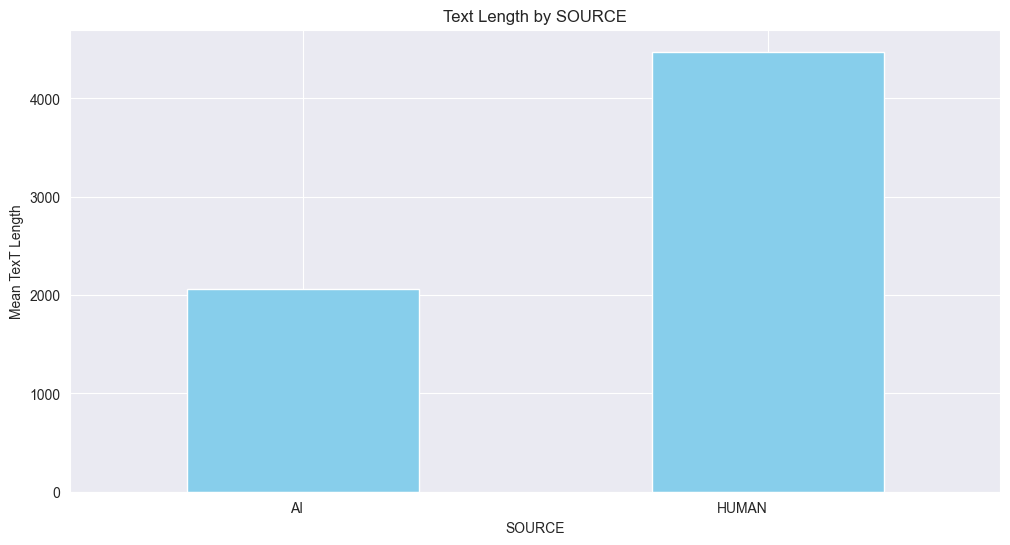

In [7]:
mean_prices_by_sublocality = df.groupby('source_binary')['text_length'].mean().sort_values()
print(mean_prices_by_sublocality)
# Bar plot for mean prices by LOCALITY
plt.figure(figsize=(12, 6))
mean_prices_by_sublocality.plot(kind='bar', color='skyblue')
plt.title('Text Length by SOURCE')
plt.xlabel('SOURCE')
plt.ylabel('Mean TexT Length')

plt.xticks(rotation=0, ha='right') # Rotate x-axis labels for better readability
plt.show()

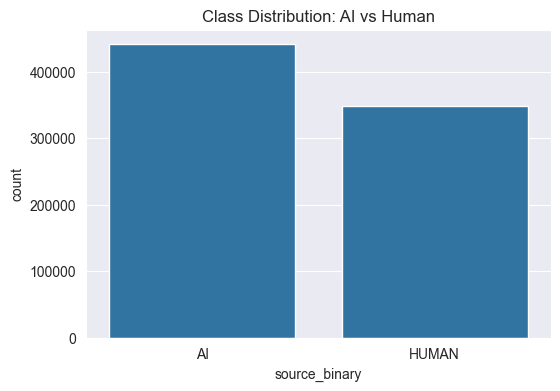

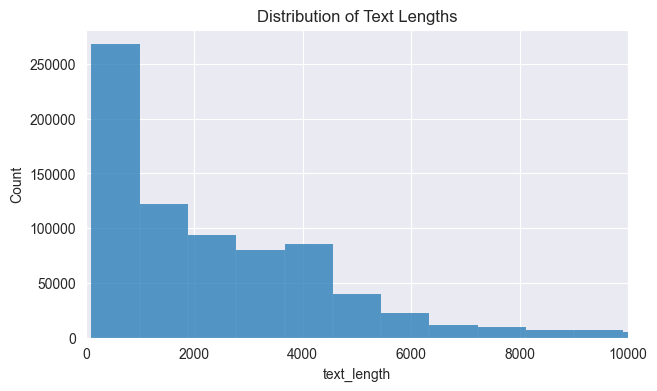

In [8]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="source_binary")
plt.title("Class Distribution: AI vs Human")
plt.show()

# TITLE LENGTH DISTRIBUTION
plt.figure(figsize=(7,4))
sns.histplot(df["text_length"], bins=1000)
plt.title("Distribution of Text Lengths")
plt.xlim(0, 10000)
plt.show() #we can see that most title length are in the 8-15 range

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X_tfidf = tfidf.fit_transform(df['clean_text'])

In [10]:
import re
#sentence count
df['sentence_count'] = df['text'].apply(
    lambda x: len(re.findall(r'[.!?]+', x))
)

In [11]:
import textstat

df['flesch'] = df['text'].apply(textstat.flesch_reading_ease)

In [12]:
import string

def punct_density(text):
    punct = sum(1 for c in text if c in string.punctuation)
    words = len(text.split())
    return punct / (words + 1)

df['punct_density'] = df['text'].apply(punct_density)

df.to_csv("final.csv", index=False)

In [ ]:
extra_features = df[
    ['word_count', 'sentence_count', 'avg_sentence_length',
     'flesch', 'punct_density'] #'noun_ratio', 'verb_ratio', 'adj_ratio']
].values

In [13]:
# !python -m spacy download en_core_web_sm
# import spacy
#
# nlp = spacy.load("en_core_web_sm")
#
# def pos_ratios(text):
#     doc = nlp(text)
#     total = len(doc)
#
#     noun = sum(1 for token in doc if token.pos_ == 'NOUN')
#     verb = sum(1 for token in doc if token.pos_ == 'VERB')
#     adj  = sum(1 for token in doc if token.pos_ == 'ADJ')
#
#     return noun/total, verb/total, adj/total
#
# df[['noun_ratio', 'verb_ratio', 'adj_ratio']] = df['text'].apply(
#     lambda x: pd.Series(pos_ratios(x))
# )

     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ----- ---------------------------------- 1.8/12.8 MB 9.6 MB/s eta 0:00:02
     ------------- -------------------------- 4.2/12.8 MB 10.8 MB/s eta 0:00:01
     ------------------ --------------------- 6.0/12.8 MB 10.1 MB/s eta 0:00:01
     ------------------------- -------------- 8.1/12.8 MB 10.0 MB/s eta 0:00:01
     ------------------------------- -------- 10.0/12.8 MB 9.8 MB/s eta 0:00:01
     ------------------------------------- -- 12.1/12.8 MB 9.8 MB/s eta 0:00:01
     ---------------------------------------- 12.8/12.8 MB 9.7 MB/s  0:00:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


KeyboardInterrupt: 

In [ ]:
from sklearn.model_selection import train_test_split

y = df['label']

X_train_tfidf, X_test_tfidf, y_train, y_test = train_test_split(
    X_tfidf,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)